In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')

print(f"Shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.2%}")
print(f"Missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
df.columns.tolist()

df.head()

Shape: (307511, 122)
Default rate: 8.07%
Missing values (top 10):
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


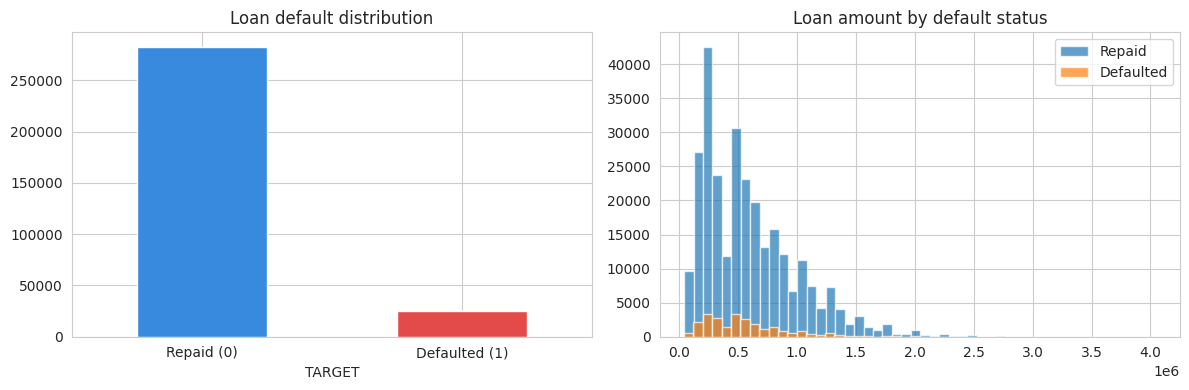

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['TARGET'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#378ADD', '#E24B4A'])
axes[0].set_title('Loan default distribution')
axes[0].set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

# Loan amount by default status
df.groupby('TARGET')['AMT_CREDIT'].hist(alpha=0.7,
    bins=50, ax=axes[1])
axes[1].set_title('Loan amount by default status')
axes[1].legend(['Repaid', 'Defaulted'])

plt.tight_layout()
plt.show()

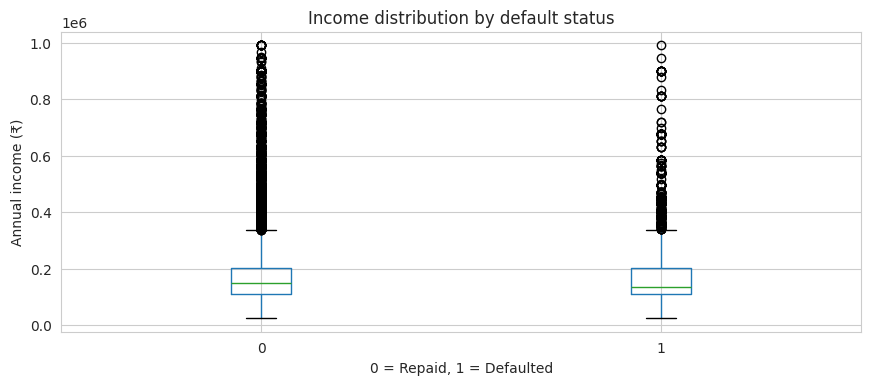

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
df[df['AMT_INCOME_TOTAL'] < 1000000].boxplot(
    column='AMT_INCOME_TOTAL',
    by='TARGET', ax=ax)
ax.set_title('Income distribution by default status')
ax.set_xlabel('0 = Repaid, 1 = Defaulted')
ax.set_ylabel('Annual income (₹)')
plt.suptitle('')
plt.show()

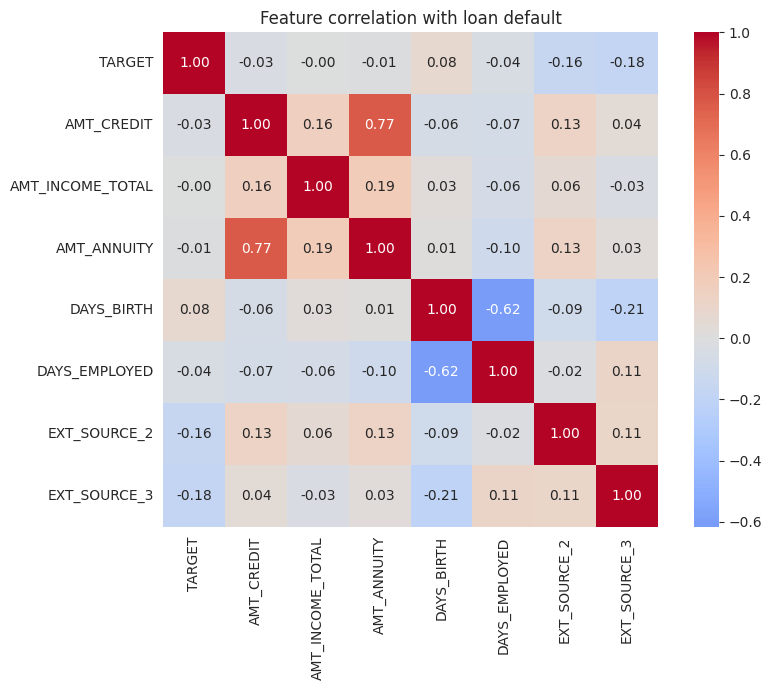

In [11]:

num_cols = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
            'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
            'EXT_SOURCE_2', 'EXT_SOURCE_3']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f',
           cmap='coolwarm', center=0, square=True)
plt.title('Feature correlation with loan default')
plt.tight_layout()
plt.show()

EXT_SOURCE_2 and EXT_SOURCE_3 show the strongest negative correlation with default (-0.16, -0.18) — these external credit scores are the most predictive single features.

In [12]:

df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Feature 3: Age in years (negative days = past)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

# Feature 4: Employment length in years
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'].clip(upper=0) / 365

# Feature 5: Combined external credit score
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_2',
    'EXT_SOURCE_3']].mean(axis=1)

print("New features created:", ['DEBT_TO_INCOME',
    'ANNUITY_TO_INCOME', 'AGE_YEARS',
    'EMPLOYMENT_YEARS', 'EXT_SOURCE_MEAN'])
df[['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME',
    'TARGET']].groupby('TARGET').mean()

New features created: ['DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'EXT_SOURCE_MEAN']


,DEBT_TO_INCOME,ANNUITY_TO_INCOME
TARGET,,
0,3.963729,0.180530
1,3.887438,0.185482


In [13]:
features = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
            'DAYS_BIRTH', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'DEBT_TO_INCOME', 'ANNUITY_TO_INCOME',
            'AGE_YEARS', 'EMPLOYMENT_YEARS', 'EXT_SOURCE_MEAN']

X = df[features].fillna(df[features].median())
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Default rate in test: {y_test.mean():.2%}")

Train size: 246,008
Test size:  61,503
Default rate in test: 8.07%


In [14]:
# Model 1: Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100,
    max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}")
print(f"Random Forest AUC-ROC:       {rf_auc:.4f}")

Logistic Regression AUC-ROC: 0.7113
Random Forest AUC-ROC:       0.7254


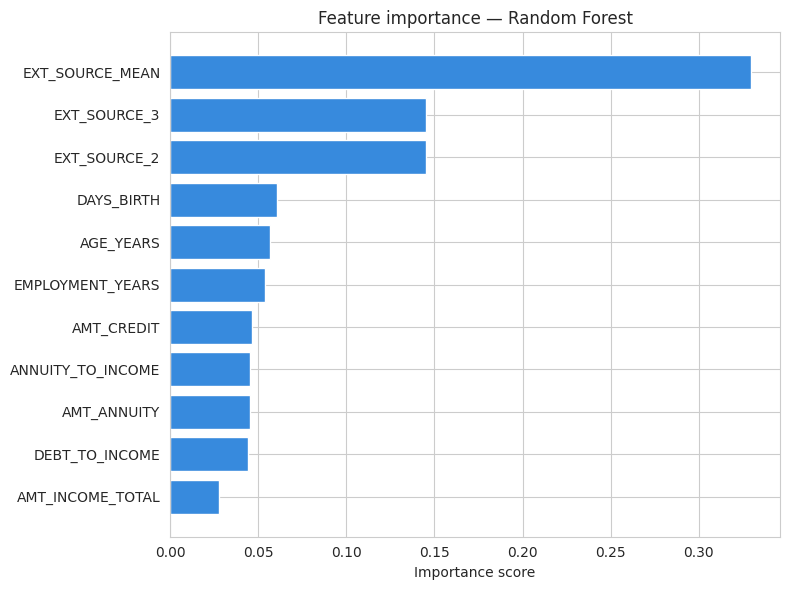

In [17]:
# Which features drive default prediction?
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'],
        color='#378ADD')
plt.title('Feature importance — Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Baseline model (11 features, no tuning) · AUC-ROC: 0.73 · 
Next steps: XGBoost, SMOTE for class imbalance, 
hyperparameter tuning expected to push AUC to ~0.78+